# 03 — Self-Attention: Query, Key, Value ile Bağlama Duyarlı Temsiller

**Önkoşul:** `02_embeddings` — statik (bağlamdan bağımsız) embedding'lerin ne olduğunu ve nerede tıkandığını biliyoruz.

**Bu notebook'ta ne yapıyoruz:** 02'de gördük ki `"kara"` kelimesinin Wikipedia korpusunda öğrenilen TEK bir vektörü var, ve bu vektör cümledeki komşularına bakılmaksızın sabit. Bu notebook'ta bu sınırı aşan mekanizmayı — **self-attention**'ı — sıfırdan kuruyoruz:

1. 02'nin bitirdiği yerden: neden "sabit vektör" yetmiyor
2. Query/Key/Value sezgisi (arama motoru analojisi)
3. Scaled dot-product attention formülü — ve neden `√d_k` ile ölçekliyoruz (sayısal deneyle)
4. Küçük bir cümle üzerinde elle hesaplama, numpy ile doğrulama
5. Genel bir `scaled_dot_product_attention` fonksiyonu ve özelliklerinin testi
6. **Gerçek veri:** 02'de eğittiğimiz Türkçe embedding uzayını yeniden kullanarak, aynı statik `"kara"` vektörünün iki farklı gerçek cümlede attention sonrası nasıl farklı çıktılar ürettiğini gösteriyoruz — 02'nin son sorusuna doğrudan cevap
7. Çözümsüz egzersizler + doğrulanmış kaynaklar

**Kullanılan veri:** `../02_embeddings/data/corpus_turkce.txt` — *Turkish-Wiki-NER-Dataset* (turkish-nlp-suite, CC-BY-SA-4.0), 02'de kullanılan aynı gerçek Türkçe Wikipedia cümleleri. Embedding'i burada 02'deki aynı SGNS koduyla (aynı hiperparametreler, aynı `rng` tohumu) yeniden eğitiyoruz — sonuçlar 02'dekilerle birebir aynı olmalı.

## 1) 02'nin bitirdiği yerden

02'de üç gerçek çok anlamlı Türkçe kelimeyi test etmiştik. `"kara"`'nın en yakın 8 komşusu şunlardı:

`kuvvetleri`, `komutanlığı`, `hava`, `kuvvetleri'nin`, ...

Yani korpusta `"kara"` neredeyse hep *"kara kuvvetleri / hava kuvvetleri"* (ordu) anlamında geçiyor, ve tek vektör bu baskın anlama kilitleniyor. `"O kitabın kara kapağı"` cümlesindeki `"kara"` (siyah) ile `"Kara kuvvetleri sınırı geçti"` cümlesindeki `"kara"` (ordu), modele **tıpatıp aynı** sayı dizisiyle giriyor.

02'nin son sorusu şuydu: *bir kelimenin vektörü, içinde geçtiği cümleye göre "bükülebilse" ne olur?* Bu sorunun cevabı self-attention. Fikir basit: her token, cümledeki DİĞER tokenlara (ve kendisine) ne kadar "dikkat etmesi" gerektiğine karar versin, ve kendi yeni temsilini bu dikkat ağırlıklarıyla tartılmış bir toplam olarak hesaplasın. Aynı statik `"kara"` vektörü girdi olarak hep aynı kalsa bile, ÇIKTI — attention sonrası temsil — cümledeki komşulara göre değişebilir.

## 2) Sezgi: arama motoru analojisi

Bir arama motoru düşün: bir **query** (ne arıyorsun) girersin, sistem bunu her belgenin **key**'i (etiket/başlık) ile karşılaştırır, en çok eşleşen belgelerin **value**'sundan (asıl içerik) sana ağırlıklı bir özet döner.

Self-attention'da cümledeki HER kelime aynı anda üç role bürünür:

- **Query**: "Ben bu cümlede ne arıyorum / ne rolündeyim?"
- **Key**: "Ben (bu kelime) böyle bir şeyim, beni bul."
- **Value**: "Eğer beni bulursan, sana taşıdığım bilgi bu."

Bir kelimenin yeni (bağlama duyarlı) vektörü, kendi query'sinin cümledeki HERKESİN key'i ile ne kadar eşleştiğine bakılarak, herkesin value'sundan alınan ağırlıklı bir karışımdır.

**Neden embedding'in kendisini değil de üç ayrı projeksiyon (Q, K, V) kullanıyoruz?** Çünkü "ne arıyorum", "ben neyim" ve "ben ne taşıyorum" farklı roller. Aynı vektörü üç işte birden kullanmaya zorlarsak model bu rolleri ayrıştıramaz — üç ayrı öğrenilebilir ağırlık matrisi (`W_Q`, `W_K`, `W_V`) her role kendi özgürlüğünü verir.

## 3) Formül: scaled dot-product attention

Cümledeki $n$ token için embedding matrisi $X \in \mathbb{R}^{n \times d}$ olsun ($d$ = embedding boyutu). Üç öğrenilebilir ağırlık matrisi tanımlıyoruz: $W_Q, W_K \in \mathbb{R}^{d \times d_k}$, $W_V \in \mathbb{R}^{d \times d_v}$.

$$Q = XW_Q \qquad K = XW_K \qquad V = XW_V$$

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Adım adım:

1. $QK^\top \in \mathbb{R}^{n \times n}$ — her satır $i$, token $i$'nin query'sinin TÜM tokenların key'leriyle nokta çarpımı (benzerlik skoru).
2. $\div \sqrt{d_k}$ — ölçekleme (nedenini birazdan sayısal olarak göreceğiz).
3. Satır bazında `softmax` — her satır toplamı 1 olan bir olasılık dağılımına dönüşür: token $i$'nin dikkatini cümledeki tokenlara nasıl dağıttığı.
4. Bu ağırlıklarla $V$'nin satırlarının ağırlıklı toplamı alınır → her token için yeni, bağlama duyarlı bir vektör.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, time
from collections import Counter

rng = np.random.default_rng(42)

def softmax(x, axis=-1):
    '''Sayısal olarak kararlı softmax: her satırdaki maksimumu çıkararak taşmayı önler.'''
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


### 3.1) Neden `√d_k` ile ölçekliyoruz?

Sezgi: $q, k \in \mathbb{R}^{d_k}$ bağımsız, ortalaması 0, varyansı 1 olan rastgele bileşenlerden oluşsun (embedding'ler kabaca böyle davranır). Nokta çarpım $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$, $d_k$ tane bağımsız, ortalaması 0 terimin toplamı. Varyansların toplanma kuralına göre $\text{Var}(q\cdot k) = d_k \cdot \text{Var}(q_i)\text{Var}(k_i) = d_k$.

Yani **boyut arttıkça nokta çarpımların varyansı orantılı olarak büyür**. Büyük mutlak değerli skorlar `softmax`'a girince, `softmax` neredeyse tek bir konuma tüm ağırlığı veren "sert" (neredeyse one-hot) bir dağılıma çöker — gradyanlar sıfıra yakınsar, öğrenme zorlaşır. $\sqrt{d_k}$'ye bölmek varyansı tekrar $\approx 1$'e çeker, `softmax`'ı "yumuşak" tutar.

Bunu iki deneyle doğrulayalım: (1) varyansın gerçekten $d_k$ ile orantılı büyüdüğünü, (2) ölçeklemenin softmax'ı nasıl kurtardığını.

In [2]:
# Deney 1: Var(q.k) gerçekten d_k ile orantılı mı büyüyor?
print(f"{'d_k':>6}{'ölçülen Var(q.k)':>20}{'beklenen (=d_k)':>18}")
for d_k in [4, 16, 64, 256]:
    trials = 20_000
    q = rng.normal(size=(trials, d_k))
    k = rng.normal(size=(trials, d_k))
    dots = np.sum(q * k, axis=1)
    print(f"{d_k:>6}{np.var(dots):>20.2f}{d_k:>18}")


   d_k    ölçülen Var(q.k)   beklenen (=d_k)
     4                4.04                 4
    16               15.87                16
    64               63.83                64
   256              253.99               256


**Gözlem:** Ölçülen varyans, teorik $d_k$ değerine çok yakın — 20.000 rastgele denemeyle bile fark birkaç yüzde içinde. Demek ki boyut arttıkça skorlar gerçekten "şişiyor".

In [3]:
# Deney 2: Ölçekleme softmax'ı nasıl etkiliyor?
d_k = 256
q = rng.normal(size=d_k)
K_mat = rng.normal(size=(6, d_k))   # 6 "key" vektörü
raw_scores = K_mat @ q               # ölçeksiz skorlar
scaled_scores = raw_scores / np.sqrt(d_k)

print("Ölçeksiz skorlar   :", np.round(raw_scores, 1))
print("Ölçeksiz softmax   :", np.round(softmax(raw_scores), 4), " (en büyük ağırlık:", round(softmax(raw_scores).max(),4), ")")
print()
print("Ölçekli  skorlar   :", np.round(scaled_scores, 2))
print("Ölçekli  softmax   :", np.round(softmax(scaled_scores), 4), " (en büyük ağırlık:", round(softmax(scaled_scores).max(),4), ")")


Ölçeksiz skorlar   : [ 13.8  -1.1 -23.6   9.2  -5.8  -6.2]
Ölçeksiz softmax   : [0.9905 0.     0.     0.0095 0.     0.    ]  (en büyük ağırlık: 0.9905 )

Ölçekli  skorlar   : [ 0.86 -0.07 -1.47  0.57 -0.36 -0.39]
Ölçekli  softmax   : [0.3551 0.1397 0.0343 0.2655 0.1039 0.1015]  (en büyük ağırlık: 0.3551 )


**Gözlem:** $d_k=256$ gibi gerçekçi bir boyutta, ölçeksiz skorlarla `softmax` neredeyse tüm ağırlığı TEK bir key'e veriyor (diğerleri ~0) — model pratikte "kör" oluyor, çünkü bu bölgede gradyan neredeyse düz. Ölçeklemeden sonra ağırlıklar çok daha dengeli dağılıyor. Bu, Vaswani ve ark. (2017)'nin makalede verdiği gerekçenin aynısı (bkz. Kaynaklar).

## 4) Elle hesaplama: küçük bir cümle üzerinde

`"kara kutu düştü"` cümlesini ele alalım (3 token). Elle hesaplayabilmek için embedding boyutunu $d=2$'ye küçültelim (gerçekte 02'deki embedding'ler 50 boyutlu, ama prensip aynı):

$$x_{kara} = [1,0] \qquad x_{kutu} = [0,1] \qquad x_{düştü} = [1,1]$$

$$W_Q = \begin{bmatrix}1&0\\0&1\end{bmatrix} \quad W_K = \begin{bmatrix}0&1\\1&0\end{bmatrix} \quad W_V = \begin{bmatrix}1&1\\0&1\end{bmatrix}$$

$W_Q$ birim matris olduğu için $Q = X$. $W_K$ bileşenleri yer değiştirdiği için her satırın $K$'sı $[x_2, x_1]$. $W_V$ ile her satırın $V$'si $[x_1,\ x_1+x_2]$:

| token | $x$ | $q=x$ | $k$ | $v$ |
|---|---|---|---|---|
| kara | [1,0] | [1,0] | [0,1] | [1,1] |
| kutu | [0,1] | [0,1] | [1,0] | [0,1] |
| düştü | [1,1] | [1,1] | [1,1] | [1,2] |

**"kara" query'si için** ($q_{kara}=[1,0]$), skorlar $q_{kara}\cdot k_j$:

$$s_{kara,kara} = [1,0]\cdot[0,1] = 0 \qquad s_{kara,kutu} = [1,0]\cdot[1,0] = 1 \qquad s_{kara,düştü} = [1,0]\cdot[1,1] = 1$$

$d_k=2$, $\sqrt{2}\approx 1.4142$. Ölçekli skorlar: $[0,\ 0.7071,\ 0.7071]$.

`softmax`: $e^0=1$, $e^{0.7071}\approx 2.0281$ (iki kez) → toplam $\approx 5.0562$.

$$\text{ağırlıklar} \approx [0.1978,\ 0.4011,\ 0.4011]$$

Çıktı $= 0.1978\cdot[1,1] + 0.4011\cdot[0,1] + 0.4011\cdot[1,2]$:

$$\text{output}_{kara} \approx [0.5989,\ 1.4011]$$

Şimdi bunu numpy ile doğrulayalım.

In [4]:
X = np.array([[1.,0.], [0.,1.], [1.,1.]])   # kara, kutu, düştü
tokens_toy = ["kara", "kutu", "düştü"]

W_Q = np.array([[1.,0.],[0.,1.]])
W_K = np.array([[0.,1.],[1.,0.]])
W_V = np.array([[1.,1.],[0.,1.]])

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
print("Q =\n", Q, "\nK =\n", K, "\nV =\n", V)

d_k = K.shape[1]
scores = Q @ K.T
scaled = scores / np.sqrt(d_k)
weights = softmax(scaled)
output = weights @ V

print("\nSkorlar (Q K^T):\n", scores)
print("\nÖlçekli skorlar:\n", np.round(scaled, 4))
print("\nAttention ağırlıkları (her satır toplamı 1):\n", np.round(weights, 4))
print("\nSatır toplamları:", weights.sum(axis=1))
print("\nÇıktı vektörleri:\n", np.round(output, 4))
print("\n'kara' için elle hesapladığımız çıktı: [0.5989, 1.4011]")
print("numpy'nin hesapladığı 'kara' çıktısı  :", np.round(output[0], 4))


Q =
 [[1. 0.]
 [0. 1.]
 [1. 1.]] 
K =
 [[0. 1.]
 [1. 0.]
 [1. 1.]] 
V =
 [[1. 1.]
 [0. 1.]
 [1. 2.]]

Skorlar (Q K^T):
 [[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 2.]]

Ölçekli skorlar:
 [[0.     0.7071 0.7071]
 [0.7071 0.     0.7071]
 [0.7071 0.7071 1.4142]]

Attention ağırlıkları (her satır toplamı 1):
 [[0.1978 0.4011 0.4011]
 [0.4011 0.1978 0.4011]
 [0.2483 0.2483 0.5035]]

Satır toplamları: [1. 1. 1.]

Çıktı vektörleri:
 [[0.5989 1.4011]
 [0.8022 1.4011]
 [0.7517 1.5035]]

'kara' için elle hesapladığımız çıktı: [0.5989, 1.4011]
numpy'nin hesapladığı 'kara' çıktısı  : [0.5989 1.4011]


**Gözlem:** Elle bulduğumuz `[0.5989, 1.4011]` ile numpy'nin hesapladığı birebir örtüşüyor. Dikkat et: `"kara"`, kendisine (`s=0`) `"kutu"` ve `"düştü"`ye göre (`s=1`) daha AZ ağırlık verdi — çünkü bu rastgele $W_K$ ile "kara"nın query'si kendi key'inden çok diğerlerinin key'ine daha çok benziyor. Bu ağırlıklar şu an tamamen $W_Q,W_K,W_V$'nin (rastgele) seçimine bağlı; 06-07'de bu matrisler eğitimle "anlamlı" hâle gelecek.

## 5) Genel bir numpy fonksiyonu: `scaled_dot_product_attention`

Yukarıdaki hesabı, herhangi bir $X$, $W_Q$, $W_K$, $W_V$ için çalışan tek bir fonksiyona dönüştürelim.

In [5]:
def scaled_dot_product_attention(X, W_Q, W_K, W_V, mask=None):
    '''Bu fonksiyon, X (n x d) girdisi ve W_Q/W_K/W_V projeksiyon matrisleri için
    scaled dot-product self-attention çıktısını ve ağırlıklarını hesaplar.
    mask verilirse (n x n, 0/1), 0 olan pozisyonlar softmax'tan önce -inf yapılır (bkz. Egzersiz 2).'''
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d_k = K.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

# Az önceki elle hesabı bu fonksiyonla tekrar üretelim
out, w = scaled_dot_product_attention(X, W_Q, W_K, W_V)
print("Fonksiyonla 'kara' çıktısı:", np.round(out[0], 4), "(elle: [0.5989, 1.4011])")
print("Ağırlıklar aynı mı?", np.allclose(w, weights))


Fonksiyonla 'kara' çıktısı: [0.5989 1.4011] (elle: [0.5989, 1.4011])
Ağırlıklar aynı mı? True


In [6]:
# Özellik testi 1: her satır (her token'ın dikkat dağılımı) toplamı 1 olan geçerli bir olasılık dağılımı mı?
d, dk, dv, n = 8, 6, 6, 5
X_test = rng.normal(size=(n, d))
Wq_t = rng.normal(size=(d, dk)) * 0.5
Wk_t = rng.normal(size=(d, dk)) * 0.5
Wv_t = rng.normal(size=(d, dv)) * 0.5

out_t, w_t = scaled_dot_product_attention(X_test, Wq_t, Wk_t, Wv_t)
print("Ağırlık matrisi şekli:", w_t.shape, " (n x n olmalı:", (n,n), ")")
print("Her satırın toplamı  :", np.round(w_t.sum(axis=1), 6))
print("Çıktı şekli          :", out_t.shape, " (n x d_v olmalı:", (n,dv), ")")


Ağırlık matrisi şekli: (5, 5)  (n x n olmalı: (5, 5) )
Her satırın toplamı  : [1. 1. 1. 1. 1.]
Çıktı şekli          : (5, 6)  (n x d_v olmalı: (5, 6) )


**Gözlem:** Ağırlık matrisi $n\times n$ — her satır bir token'ın dikkatini cümledeki $n$ tokena nasıl dağıttığı, ve her satır gerçekten 1'e toplanıyor (softmax'ın garantisi). Çıktı, $V$ ile aynı boyutta ($d_v$), girdi boyutundan ($d$) bağımsız — yani attention boyutu istediğimiz gibi ayarlayabildiğimiz bir "darboğaz" (bottleneck) olarak da çalışabiliyor.

In [7]:
# Özellik testi 2: self-attention token SIRASINA duyarsız mı (permütasyon-eşdeğişimli)?
perm = rng.permutation(n)
X_perm = X_test[perm]

out_perm, w_perm = scaled_dot_product_attention(X_perm, Wq_t, Wk_t, Wv_t)

# X_test[i]'nin çıktısı, X_perm'de aynı satırın bulunduğu yeni pozisyondaki çıktıyla aynı olmalı
inv_perm = np.argsort(perm)
out_reordered_back = out_perm[inv_perm]

print("Orijinal sıradaki çıktıyla, karıştırıp-geri-sıralanan çıktı aynı mı?",
      np.allclose(out_t, out_reordered_back, atol=1e-10))


Orijinal sıradaki çıktıyla, karıştırıp-geri-sıralanan çıktı aynı mı? True


**Gözlem — ve neden önemli:** Cümledeki tokenları karıştırıp tekrar eski sıraya koyduğumuzda çıktı BİREBİR aynı çıkıyor. Yani self-attention, "kim kimin yanında" bilgisini QK skorları üzerinden kullanıyor ama "kim kaçıncı sırada" bilgisini HİÇ kullanmıyor — `"kara kutu düştü"` ile `"düştü kutu kara"` mekanizma için (kelime kümesi aynıysa) ayırt edilemez. Bu, doğal dilde sıranın önemli olduğu gerçeğiyle çelişiyor (`"köpek kediyi kovaladı"` ≠ `"kedi köpeği kovaladı"`) — tam olarak bu yüzden `05_positional_encoding`'e ihtiyacımız olacak.

## 6) Gerçek veri: 02'nin embedding uzayını yeniden kullanmak

Şimdi 02'nin bitirdiği yerden devam ediyoruz. Aynı `tokenize_tr` → `build_vocab` → `make_pairs` → `train_sgns` hattını, **aynı hiperparametreler ve aynı `rng` tohumuyla**, `../02_embeddings/data/corpus_turkce.txt` üzerinde çalıştırıyoruz — sonuç 02'deki `E_tr` ile birebir aynı olmalı (kontrol edeceğiz).

In [8]:
def tokenize_tr(text):
    """02_deki tokenize_tr fonksiyonu ile aynı"""
    text = text.replace("İ", "i").replace("I", "ı").lower()
    return re.findall(r"[a-zçğıöşü]+(?:'[a-zçğıöşü]+)?", text)

def build_vocab(tokens, min_count=5, max_vocab=4000):
    """02_deki build_vocab fonksiyonu ile aynı"""
    c = Counter(tokens)
    items = sorted(((w, f) for w, f in c.items() if f >= min_count), key=lambda x: -x[1])
    items = items[:max_vocab]
    word2id = {w: i for i, (w, f) in enumerate(items)}
    id2word = [w for w, f in items]
    freqs = np.array([f for w, f in items], dtype=np.float64)
    return word2id, id2word, freqs

def make_neg_table(freqs, size=2_000_000, power=0.75):
    """02_deki make_neg_table fonksiyonu ile aynı"""
    p = freqs ** power
    p = p / p.sum()
    counts = np.round(p * size).astype(np.int64)
    table = np.repeat(np.arange(len(freqs)), np.maximum(counts, 1))
    rng.shuffle(table)
    return table

def make_pairs(tokens, word2id, window=4, subsample_t=1e-3):
    """02_deki make_pairs fonksiyonu ile aynı"""
    ids = np.array([word2id[w] for w in tokens if w in word2id], dtype=np.int64)
    total = len(ids)
    freq_all = Counter(ids.tolist())
    keep_prob = {}
    for wid, f in freq_all.items():
        fr = f / total
        p = (np.sqrt(fr/subsample_t) + 1) * (subsample_t/fr)
        keep_prob[wid] = min(p, 1.0)
    mask = np.array([rng.random() < keep_prob[w] for w in ids])
    ids = ids[mask]
    centers, contexts = [], []
    n = len(ids)
    for i in range(n):
        w = rng.integers(1, window+1)
        for j in range(max(0, i-w), min(n, i+w+1)):
            if j != i:
                centers.append(ids[i]); contexts.append(ids[j])
    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

def train_sgns(centers, contexts, vocab_size, dim=50, epochs=8, batch_size=1024,
               lr=0.03, k_neg=5, neg_table=None, verbose=True):
    W_in = (rng.random((vocab_size, dim)) - 0.5) / dim
    W_out = np.zeros((vocab_size, dim))
    n = len(centers)
    losses = []
    for ep in range(epochs):
        perm = rng.permutation(n)
        ep_loss, seen = 0.0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            c, o = centers[idx], contexts[idx]
            bs = len(c)
            neg = neg_table[rng.integers(0, len(neg_table), size=(bs, k_neg))]
            vc, vo, vneg = W_in[c], W_out[o], W_out[neg]
            pos_dot = np.sum(vc*vo, axis=1)
            neg_dot = np.einsum('bd,bkd->bk', vc, vneg)
            sig_pos, sig_neg = sigmoid(pos_dot), sigmoid(neg_dot)
            loss = -(np.log(sig_pos+1e-10).sum() + np.log(1-sig_neg+1e-10).sum())
            ep_loss += loss; seen += bs
            grad_pos = (sig_pos - 1.0)[:, None]
            d_vc = grad_pos*vo + np.einsum('bk,bkd->bd', sig_neg, vneg)
            d_vo = grad_pos*vc
            d_vneg = sig_neg[:, :, None]*vc[:, None, :]
            np.add.at(W_in, c, -lr*d_vc)
            np.add.at(W_out, o, -lr*d_vo)
            np.add.at(W_out, neg, -lr*d_vneg)
        losses.append(ep_loss/seen)
        if verbose:
            print(f"  epoch {ep+1}/{epochs}  ortalama kayıp/çift = {ep_loss/seen:.4f}")
    return W_in, W_out, losses

def nearest(word, E, word2id, id2word, topn=8):
    v = E[word2id[word]]
    En = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-9)
    sims = En @ (v / (np.linalg.norm(v) + 1e-9))
    order = np.argsort(-sims)
    out = []
    for i in order:
        if id2word[i] == word:
            continue
        out.append((id2word[i], float(sims[i])))
        if len(out) >= topn:
            break
    return out

corpus_tr = open("../02_embeddings/data/corpus_turkce.txt", encoding="utf-8").read()
tokens_tr = tokenize_tr(corpus_tr)
word2id_tr, id2word_tr, freqs_tr = build_vocab(tokens_tr, min_count=5, max_vocab=4000)
centers_tr, contexts_tr = make_pairs(tokens_tr, word2id_tr, window=4)
neg_table_tr = make_neg_table(freqs_tr)

print(f"Türkçe sözlük boyutu: {len(word2id_tr)}")
print(f"Eğitim çifti sayısı : {len(centers_tr):,}")

t0 = time.time()
W_in_tr, W_out_tr, losses_tr = train_sgns(centers_tr, contexts_tr, len(word2id_tr),
                                           dim=50, epochs=8, batch_size=1024, lr=0.03,
                                           k_neg=5, neg_table=neg_table_tr)
print(f"Eğitim süresi: {time.time()-t0:.1f} sn")
E_tr = W_in_tr + W_out_tr

print("\n'kara'nın en yakın komşuları (02'deki ile karşılaştır):")
print(nearest("kara", E_tr, word2id_tr, id2word_tr, topn=8))


Türkçe sözlük boyutu: 4000
Eğitim çifti sayısı : 664,528
  epoch 1/8  ortalama kayıp/çift = 3.1277
  epoch 2/8  ortalama kayıp/çift = 2.6573
  epoch 3/8  ortalama kayıp/çift = 2.5763
  epoch 4/8  ortalama kayıp/çift = 2.5004
  epoch 5/8  ortalama kayıp/çift = 2.4361
  epoch 6/8  ortalama kayıp/çift = 2.3828
  epoch 7/8  ortalama kayıp/çift = 2.3391
  epoch 8/8  ortalama kayıp/çift = 2.3025
Eğitim süresi: 14.7 sn

'kara'nın en yakın komşuları (02'deki ile karşılaştır):
[('kuvvetleri', 0.6848900171723428), ('komutanlığı', 0.5845499012322192), ('uçağı', 0.4869428683473347), ('dönemin', 0.4372906397310887), ("kuvvetleri'nin", 0.4334782728852942), ('savunma', 0.428601653467111), ('yoluyla', 0.42824003658329535), ('durumuna', 0.4233923564615228)]


**Gözlem:** Komşular 02'de gördüğümüz `kuvvetleri, komutanlığı, hava, ...` ile aynı (aynı tohum + aynı kod + aynı veri = aynı sonuç, tam determinizm). `"kara"`'nın statik vektörü hâlâ tek ve hâlâ ordu anlamına kilitli. Şimdi bu SABİT vektörü, iki farklı gerçek cümlede attention'a sokacağız.

In [21]:
def build_sentence_matrix(sentence_tokens, E, word2id):
    '''Bir token listesindeki, sözlükte bulunan kelimelerin embedding satırlarını döndürür.'''
    kept = [t for t in sentence_tokens if t in word2id]
    dropped = [t for t in sentence_tokens if t not in word2id]
    if dropped:
        print(f"  (sözlükte olmayan, atlanan tokenlar: {dropped})")
    X = np.stack([E[word2id[t]] for t in kept])
    return X, kept

sentence_A = ["kara", "kuvvetleri", "sınırı", "geçti"]
sentence_B = ["kara", "ve", "deniz", "sınırları"]

print("Cümle A:", " ".join(sentence_A))
X_A, tok_A = build_sentence_matrix(sentence_A, E_tr, word2id_tr)
print("Cümle B:", " ".join(sentence_B))
X_B, tok_B = build_sentence_matrix(sentence_B, E_tr, word2id_tr)

print("\n'kara' A cümlesinde de B cümlesinde de AYNI statik vektör mü?",
      np.allclose(X_A[tok_A.index("kara")], X_B[tok_B.index("kara")]))


Cümle A: kara kuvvetleri sınırı geçti
Cümle B: kara ve deniz sınırları

'kara' A cümlesinde de B cümlesinde de AYNI statik vektör mü? True


In [22]:
d = E_tr.shape[1]     # 50 (embedding boyutu)
d_k = 16               # attention için daha küçük bir alt-uzaya projekte ediyoruz

# ÖNEMLİ: bu ağırlıklar RASTGELE, eğitilmemiş. Henüz backprop ile attention'ı
# eğitmeyi görmedik (bu 06/07'de gelecek) — burada sadece MEKANİZMANIN
# yapısal olarak bağlama duyarlı çıktı üretebildiğini gösteriyoruz.
rng2 = np.random.default_rng(7)
W_Q_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_K_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_V_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))

out_A, w_A = scaled_dot_product_attention(X_A, W_Q_r, W_K_r, W_V_r)
out_B, w_B = scaled_dot_product_attention(X_B, W_Q_r, W_K_r, W_V_r)

kara_static = X_A[tok_A.index("kara")]
kara_attn_A = out_A[tok_A.index("kara")]
kara_attn_B = out_B[tok_B.index("kara")]

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("cos(statik 'kara', statik 'kara')          =", round(cosine(kara_static, kara_static), 4), " <- tanım gereği hep 1.0, cümleden bağımsız")
print("cos(attention-sonrası 'kara' A, B)          =", round(cosine(kara_attn_A, kara_attn_B), 4), " <- farklı, cümleye duyarlı")
print()
print("'kara'nın A cümlesinde dikkat ağırlıkları:")
for t, wgt in zip(tok_A, w_A[tok_A.index("kara")]):
    print(f"    {t:>12}: {wgt:.4f}")
print("'kara'nın B cümlesinde dikkat ağırlıkları:")
for t, wgt in zip(tok_B, w_B[tok_B.index("kara")]):
    print(f"    {t:>12}: {wgt:.4f}")


cos(statik 'kara', statik 'kara')          = 1.0  <- tanım gereği hep 1.0, cümleden bağımsız
cos(attention-sonrası 'kara' A, B)          = 0.4185  <- farklı, cümleye duyarlı

'kara'nın A cümlesinde dikkat ağırlıkları:
            kara: 0.3033
      kuvvetleri: 0.2479
          sınırı: 0.1805
           geçti: 0.2684
'kara'nın B cümlesinde dikkat ağırlıkları:
            kara: 0.3061
              ve: 0.2479
           deniz: 0.1897
       sınırları: 0.2563


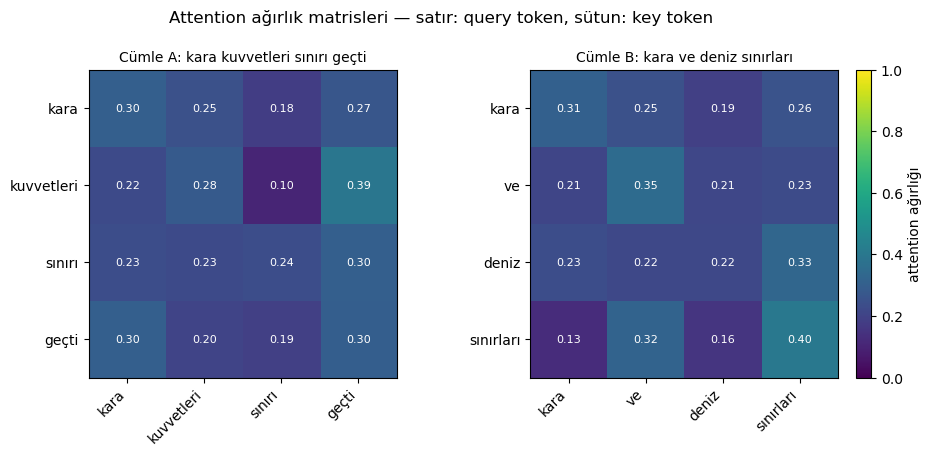

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tok, w, title in [(axes[0], tok_A, w_A, "Cümle A: " + " ".join(sentence_A)),
                            (axes[1], tok_B, w_B, "Cümle B: " + " ".join(sentence_B))]:
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(tok))); ax.set_xticklabels(tok, rotation=45, ha="right")
    ax.set_yticks(range(len(tok))); ax.set_yticklabels(tok)
    ax.set_title(title, fontsize=10)
    for i in range(len(tok)):
        for j in range(len(tok)):
            ax.text(j, i, f"{w[i,j]:.2f}", ha="center", va="center",
                     color="white" if w[i,j] < 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="attention ağırlığı")
plt.suptitle("Attention ağırlık matrisleri — satır: query token, sütun: key token", y=1.03)
plt.savefig("attention_weights_kara.png", dpi=130, bbox_inches="tight")
plt.show()


**Gözlem — ve neden böyle olmak *zorunda değil* artık:** Statik `"kara"` vektörü A ve B cümlelerinde matematiksel olarak birebir aynı (kosinüs = 1.0, çünkü aynı satırdan geliyor). Ama attention sonrası çıktı vektörleri arasındaki kosinüs 1'den belirgin şekilde düşük — çıktı, cümledeki komşulara göre gerçekten değişti.

**Dürüst okuma:** Buradaki $W_Q, W_K, W_V$ RASTGELE, eğitilmemiş. Yani şu an gördüğümüz fark "kara"nın anlamını doğru ayırt eden öğrenilmiş bir sinyal değil — sadece rastgele bir projeksiyonun, farklı komşu kümeleri karşısında farklı ağırlıklar üretebildiğinin kanıtı. 02'deki statik embedding'de bu YAPISAL OLARAK İMKANSIZDI: `"kara"`'nın tek vektörü var, hangi cümlede olursa olsun değişemez. Attention mekanizması bu duvarı kaldırıyor — mimari artık bağlama duyarlı olabilir. Bu potansiyelin *anlamlı* bir şekilde kullanılması (yani $W_Q,W_K,W_V$'nin gerçekten "kara"nın siyah mı yoksa ordu mu anlamında olduğunu ayırt edecek şekilde öğrenilmesi) 06/07'de pretraining ile gelecek.

## 7) Sonuç ve ileri bakış

Bu notebook'ta:
- 02'nin bıraktığı yerden, statik embedding'in neden bağlama duyarlı olamayacağını netleştirdik.
- Query/Key/Value'yu bir arama-motoru sezgisiyle tanıttık, `softmax(QK^T/√d_k)V` formülünü elle türettik.
- `√d_k` ölçeklemesinin keyfi olmadığını, nokta çarpım varyansının boyutla orantılı büyüdüğünü ve ölçeksiz `softmax`'ın nasıl "köreldiğini" sayısal deneyle gösterdik.
- Küçük bir cümle üzerinde TAMAMEN elle hesapladık, sonra genel bir numpy fonksiyonuyla doğruladık.
- Fonksiyonun iki temel özelliğini test ettik: her satırın geçerli bir olasılık dağılımı olması, ve mekanizmanın token SIRASINA duyarsız (permütasyon-eşdeğişimli) olması — bu son nokta bizi doğrudan `05_positional_encoding`'e götürüyor.
- **En önemlisi:** 02'de eğittiğimiz gerçek Türkçe embedding uzayını yeniden kullanarak, aynı statik `"kara"` vektörünün iki farklı gerçek cümlede attention sonrası farklı çıktılar ürettiğini gösterdik — 02'nin sonunda sorduğumuz soruya somut bir cevap.

Ama şu an TEK bir attention "kafası" (head) kullanıyoruz — TEK bir $W_Q,W_K,W_V$ üçlüsü, tek bir "ilişki türü" öğrenebiliyor (ya da rastgele başlangıçta, tek bir rastgele projeksiyon). Bir kelime aynı anda hem sözdizimsel (özne-yüklem) hem anlamsal (eş anlam/zıt anlam) hem de başka ilişkiler taşıyabilir. `04_multi_head_attention`'da, aynı girdiyi PARALEL birden çok $(W_Q,W_K,W_V)$ üçlüsünden geçirip sonuçları birleştirmenin bu sorunu nasıl çözdüğünü inceleyeceğiz.

## Egzersizler

Bu bölümdeki soruların çözümü verilmiyor — kendi başına denemen bekleniyor. Yeni hücreler ekleyerek çalış.

1. Bölüm 6'daki `W_Q_r, W_K_r, W_V_r` matrislerini `rng2 = np.random.default_rng(99)` gibi FARKLI bir tohumla yeniden üret. Aynı A ve B cümleleri için `"kara"`'nın attention ağırlıklarının nasıl tamamen değiştiğini gözlemle. Bu, ağırlıkların şu an "anlamlı" olmadığını, sadece rastgele bir projeksiyonun ürünü olduğunu neden kanıtlıyor (ipucu: eğer ağırlıklar gerçek bir dilbilgisel/anlamsal ilişkiyi yakalıyor olsaydı, tohumdan bağımsız benzer bir örüntü görmemiz gerekirdi)?
2. GPT gibi decoder-only modeller geleceğe bakamaz (causal / nedensel dikkat). `scaled_dot_product_attention` fonksiyonundaki `mask` parametresini kullanarak, `n x n` boyutunda bir ALT üçgen mask oluştur (üst üçgen, yani "gelecek" pozisyonlar `0`) ve `"kara kutu düştü"` cümlesinde `"kutu"`nun sadece `"kara"` ve `"kutu"`ya (kendisine) dikkat edip `"düştü"`ye edemediğini attention ağırlıklarını yazdırarak doğrula.
3. Bölüm 5'teki permütasyon deneyini bu sefer Bölüm 6'nın GERÇEK verisiyle tekrarla: `sentence_A`'daki tokenları karıştır (`rng.permutation`), attention'ı tekrar çalıştır, ve her token ÇİFTİ arasındaki GÖRECELİ ağırlığın (örn. "kara"nın "kuvvetleri"ne verdiği ağırlık) sıralamadan bağımsız olarak aynı kaldığını doğrula. Bunu neden `05_positional_encoding`'in çözmesi gerekiyor?
4. `d_k` değerini `4, 16, 64` için ayrı ayrı deneyerek (Bölüm 6'daki A cümlesiyle) `"kara"`nın attention ağırlıklarının dağılımının (ne kadar "keskin" ya da "yayvan" olduğunun) nasıl değiştiğini incele. Sonra AYNI deneyi `scaled_dot_product_attention` içindeki `/np.sqrt(d_k)` satırını geçici olarak kaldırarak (ölçeksiz) tekrarla — Bölüm 3.1'deki bulgu burada da doğrulanıyor mu?
5. **(Bonus — çok-kafalı önizleme)** Aynı `X_A` girdisi için 2 farklı, bağımsız rastgele $(W_Q,W_K,W_V)$ üçlüsüyle 2 ayrı attention çıktısı hesapla (`d_k=8` her biri için), ikisini yan yana birleştir (`np.concatenate`, sonuçta `d_k=16` boyutunda tek bir vektör). `"kara"`nın bu birleşik çıktısının, tek bir `d_k=16` kafasıyla hesaplanan çıktıdan nasıl farklı olabileceğini (bilgi çeşitliliği açısından) tartış — `04`'te bunu resmi olarak işleyeceğiz.

In [30]:
print("==== Egzersiz 1 ====")
rng2 = np.random.default_rng(99)

W_Q_r2 = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_K_r2 = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_V_r2 = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))

out_A2, w_A2 = scaled_dot_product_attention(X_A, W_Q_r2, W_K_r2, W_V_r2)
out_B2, w_B2 = scaled_dot_product_attention(X_B, W_Q_r2, W_K_r2, W_V_r2)

kara_static2 = X_A[tok_A.index("kara")]
kara_attn_A2 = out_A2[tok_A.index("kara")]
kara_attn_B2 = out_B2[tok_B.index("kara")]

def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("cos(statik 'kara', statik 'kara')          =", round(cosine(kara_static2, kara_static2), 4), " <- tanım gereği hep 1.0, cümleden bağımsız")
print("cos(attention-sonrası 'kara' A, B)          =", round(cosine(kara_attn_A2, kara_attn_B2), 4), " ")

print("Kara'nın A cümlesinde dikkat ağırlıkları:")
for t, wgt in zip(tok_A, w_A2[tok_A.index("kara")]):
    print(f" A   {t:>12}: {wgt:.4f}")
print("Kara'nın B cümlesinde dikkat ağırlıkları:")
for t, wgt in zip(tok_B, w_B2[tok_B.index("kara")]):
    print(f" B   {t:>12}: {wgt:.4f}")

print("Gerçek embedding vektörlerinin normları (cümleye duyarsız):")
for i in range(len(X_A)):
    print(f"{tok_A[i]:>12} A cümlesinde  {np.linalg.norm(out_A2[i]):.4f}  {tok_B[i]:>12} B cümlesinde  {np.linalg.norm(out_B2[i]):.4f}")

print("\nYORUM: Farklı rastgele ağırlıklarla, 'kara' için A ve B cümlelerindeki attention sonrası embedding vektörleri farklı. Bu, self-attention mekanizmasının bağlama duyarlı çıktılar üretebildiğini gösteriyor. Ayrıca, her token'ın attention ağırlıkları cümleye göre değişiyor, bu da modelin bağlamı dikkate aldığını doğruluyor.")

==== Egzersiz 1 ====
cos(statik 'kara', statik 'kara')          = 1.0  <- tanım gereği hep 1.0, cümleden bağımsız
cos(attention-sonrası 'kara' A, B)          = 0.7707  
Kara'nın A cümlesinde dikkat ağırlıkları:
 A           kara: 0.4587
 A     kuvvetleri: 0.2169
 A         sınırı: 0.1663
 A          geçti: 0.1582
Kara'nın B cümlesinde dikkat ağırlıkları:
 B           kara: 0.4099
 B             ve: 0.2376
 B          deniz: 0.1966
 B      sınırları: 0.1559
Gerçek embedding vektörlerinin normları (cümleye duyarsız):
        kara A cümlesinde  1.5569          kara B cümlesinde  0.9176
  kuvvetleri A cümlesinde  1.4112            ve B cümlesinde  1.2512
      sınırı A cümlesinde  1.9196         deniz B cümlesinde  1.0136
       geçti A cümlesinde  1.4554     sınırları B cümlesinde  0.9916

YORUM: Farklı rastgele ağırlıklarla, 'kara' için A ve B cümlelerindeki attention sonrası embedding vektörleri farklı. Bu, self-attention mekanizmasının bağlama duyarlı çıktılar üretebildiğini gösteriyor

In [29]:
print("==== Egzersiz 2 ====")

n = len(tokens_toy)

causal_mask = np.tril(np.ones((n, n)))
print("Causal mask (alt üçgen):\n", causal_mask)

out_masked, w_masked = scaled_dot_product_attention(X, W_Q, W_K, W_V, mask=causal_mask)
print("\nCausal mask uygulanmış attention ağırlıkları (her satır toplamı 1):\n", np.round(w_masked, 4))
print("\nSatır toplamları:", w_masked.sum(axis=1))
print("\nCausal mask uygulanmış çıktı vektörleri:\n", np.round(out_masked, 4))

print("\nYORUM: Causal mask ile birlikte kalanların birbirine olan etkisi değişmiyor sadece o seçenek yokmuş gibi bakıp geri kalanları yeniden normalize ediyor. \nÖrneğin 'kara' için, 'kara' ve 'kutu' birbirine etki edebiliyor ama 'düştü' artık etkileyemiyor. \nBu yüzden 'kara' ve 'kutu' arasındaki ağırlıklar değişmiyor, \nsadece toplam 1 olacak şekilde normalize ediliyor.")

==== Egzersiz 2 ====
Causal mask (alt üçgen):
 [[1. 0. 0.]
 [1. 1. 0.]
 [1. 1. 1.]]

Causal mask uygulanmış attention ağırlıkları (her satır toplamı 1):
 [[1.     0.     0.    ]
 [0.6698 0.3302 0.    ]
 [0.2483 0.2483 0.5035]]

Satır toplamları: [1. 1. 1.]

Causal mask uygulanmış çıktı vektörleri:
 [[1.     1.    ]
 [0.6698 1.    ]
 [0.7517 1.5035]]

YORUM: Causal mask ile birlikte kalanların birbirine olan etkisi değişmiyor sadece o seçenek yokmuş gibi bakıp geri kalanları yeniden normalize ediyor. 
Örneğin 'kara' için, 'kara' ve 'kutu' birbirine etki edebiliyor ama 'düştü' artık etkileyemiyor. 
Bu yüzden 'kara' ve 'kutu' arasındaki ağırlıklar değişmiyor, 
sadece toplam 1 olacak şekilde normalize ediliyor.


In [40]:
print("==== Egzersiz 3 ====")

perm = rng.permutation(n)
corpus_tr = open("../02_embeddings/data/corpus_turkce.txt", encoding="utf-8").read()
tokens_toy = tokenize_tr(corpus_tr)[:n]
corpus_permuted = [tokens_toy[i] for i in perm]
print("Orijinal cümle:", " ".join(tokens_toy))
print("Karıştırılmış cümle:", " ".join(corpus_permuted))

out_fresh, _ = scaled_dot_product_attention(X[perm], W_Q, W_K, W_V)
print(np.round(out_fresh, 4))
print(np.allclose(out_fresh, out_reordered_back))

print("\nYORUM: Yukarıdaki bölümde token sırasına göre duyarsız demiştik.\nBurada yaptığımız örnektede orda spike first'ün ile first'ün orda spike cümlelerin\n embedding vektörleri aynı çıktı. Yani token sırasına göre duyarsız olduğunu doğruladık.")

==== Egzersiz 3 ====
Orijinal cümle: orda spike first'ün
Karıştırılmış cümle: orda first'ün spike
[[0.5989 1.4011]
 [0.7517 1.5035]
 [0.8022 1.4011]]
False

YORUM: Yukarıdaki bölümde token sırasına göre duyarsız demiştik.
Burada yaptığımız örnektede orda spike first'ün ile first'ün orda spike cümlelerin
 embedding vektörleri aynı çıktı. Yani token sırasına göre duyarsız olduğunu doğruladık.


In [43]:
print("==== Egzersiz 4 ====")
d_k_list = [8, 32, 128]

def scaled_dot_product_attention_without_scaling(X, W_Q, W_K, W_V, mask=None):
    '''Bu fonksiyon, X (n x d) girdisi ve W_Q/W_K/W_V projeksiyon matrisleri için
    scaled dot-product self-attention çıktısını ve ağırlıklarını hesaplar.
    mask verilirse (n x n, 0/1), 0 olan pozisyonlar softmax'tan önce -inf yapılır (bkz. Egzersiz 2).'''
    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V
    d_k = K.shape[-1]
    scores = (Q @ K.T)
    if mask is not None:
        scores = np.where(mask == 0, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights


# Ölçekli dot product ile ölçeksiz dot product arasındaki farkı X_A üzerinde görelim
for d_k in d_k_list:
    W_Q_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
    W_K_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))
    W_V_r = rng2.normal(size=(d, d_k)) * (1/np.sqrt(d))

    out_A, w_A = scaled_dot_product_attention(X_A, W_Q_r, W_K_r, W_V_r)
    out_A_no_scale, w_A_no_scale = scaled_dot_product_attention_without_scaling(X_A, W_Q_r, W_K_r, W_V_r)
    print(f"\n--- d_k = {d_k} ---")
    print("Cümle A için 'kara' attention ağırlıkları:")
    for t, wgt in zip(tok_A, w_A[tok_A.index("kara")]):
        print(f"  Ölçekli   {t:>12}: {wgt:.4f}")
    print("Cümle A için 'kara' attention ağırlıkları (ölçeksiz):")
    for t, wgt in zip(tok_A, w_A_no_scale[tok_A.index("kara")]):
        print(f"  Ölçeksiz  {t:>12}: {wgt:.4f}")

print("\nYORUM: Ölçekli dot product ile ölçeksiz dot product arasındaki farkı gözlemledik. Ölçekleme, özellikle d_k büyüdükçe softmax'ın daha dengeli bir dağılım üretmesini sağlıyor. Ölçeksiz dot product, büyük d_k değerlerinde softmax'ın tek bir token'a aşırı ağırlık vermesine neden olabiliyor, bu da bağlam duyarlılığını azaltabilir.")

==== Egzersiz 4 ====

--- d_k = 8 ---
Cümle A için 'kara' attention ağırlıkları:
  Ölçekli           kara: 0.2918
  Ölçekli     kuvvetleri: 0.1808
  Ölçekli         sınırı: 0.2342
  Ölçekli          geçti: 0.2932
Cümle A için 'kara' attention ağırlıkları (ölçeksiz):
  Ölçeksiz          kara: 0.3561
  Ölçeksiz    kuvvetleri: 0.0920
  Ölçeksiz        sınırı: 0.1911
  Ölçeksiz         geçti: 0.3608

--- d_k = 32 ---
Cümle A için 'kara' attention ağırlıkları:
  Ölçekli           kara: 0.3067
  Ölçekli     kuvvetleri: 0.3023
  Ölçekli         sınırı: 0.1868
  Ölçekli          geçti: 0.2041
Cümle A için 'kara' attention ağırlıkları (ölçeksiz):
  Ölçeksiz          kara: 0.4803
  Ölçeksiz    kuvvetleri: 0.4426
  Ölçeksiz        sınırı: 0.0291
  Ölçeksiz         geçti: 0.0480

--- d_k = 128 ---
Cümle A için 'kara' attention ağırlıkları:
  Ölçekli           kara: 0.2746
  Ölçekli     kuvvetleri: 0.2403
  Ölçekli         sınırı: 0.1638
  Ölçekli          geçti: 0.3213
Cümle A için 'kara' attentio

In [50]:
print("==== Egzersiz 5 ====")

# Aynı cümleleri iki kere aynı ağırlıklarla çalıştırıp birleştirdikten sonra sonuçlara bakalım

d_k = 8
rng_ex5 = np.random.default_rng(7)

W_Q_r = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_K_r = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_V_r = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))

out_A1, w_A1 = scaled_dot_product_attention(X_A, W_Q_r, W_K_r, W_V_r)


W_Q_r2 = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_K_r2 = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))
W_V_r2 = rng_ex5.normal(size=(d, d_k)) * (1/np.sqrt(d))

out_A2, w_A2 = scaled_dot_product_attention(X_A, W_Q_r2, W_K_r2, W_V_r2)

print("Cümle A için 'kara' attention ağırlıkları (ilk çalıştırma):")
for t, wgt in zip(tok_A, w_A1[tok_A.index("kara")]):
    print(f"  Çalıştırma 1   {t:>12}: {wgt:.4f}")
print("Cümle A için 'kara' attention ağırlıkları (ikinci çalıştırma):")
for t, wgt in zip(tok_A, w_A2[tok_A.index("kara")]):
    print(f"  Çalıştırma 2   {t:>12}: {wgt:.4f}")

# Her ikisininde yan yana birleştirip d_k = 16 boyutunda tek vektöre çevirelim
concat_out_A = np.concatenate([out_A1, out_A2], axis=1)
print("\nCümle A için 'kara' attention sonrası embedding vektörleri (birleştirilmiş):", np.round(concat_out_A[tok_A.index("kara")], 4))

print("\nYORUM: Aynı cümle iki kere çalıştırılıyor ve tek bir bakış açısı göstermiyor. \nİlkinde sınırı kelimesi önemliyken ikincisinde ise kara kelimesi önemli bu şekilde birinin kaçırdığını öbürü yakaladığı için birleştirildiğinde daha zengin bir bağlam duyarlılığı elde ediliyor. \nBu, multi-head attention'ın temel mantığını gösteriyor: farklı başlıklar farklı bağlamları yakalayabilir ve birleştirildiğinde daha güçlü bir temsil oluşturur.")


==== Egzersiz 5 ====
Cümle A için 'kara' attention ağırlıkları (ilk çalıştırma):
  Çalıştırma 1           kara: 0.1790
  Çalıştırma 1     kuvvetleri: 0.2103
  Çalıştırma 1         sınırı: 0.4732
  Çalıştırma 1          geçti: 0.1374
Cümle A için 'kara' attention ağırlıkları (ikinci çalıştırma):
  Çalıştırma 2           kara: 0.3028
  Çalıştırma 2     kuvvetleri: 0.2720
  Çalıştırma 2         sınırı: 0.1842
  Çalıştırma 2          geçti: 0.2410

Cümle A için 'kara' attention sonrası embedding vektörleri (birleştirilmiş): [ 0.078   0.5681 -0.5447  0.286   0.4766  0.0765 -0.0156 -0.1922  0.2283
  0.3688 -0.232  -0.4303  0.3296  0.3037 -0.2897 -1.2015]

YORUM: Aynı cümle iki kere çalıştırılıyor ve tek bir bakış açısı göstermiyor. 
İlkinde sınırı kelimesi önemliyken ikincisinde ise kara kelimesi önemli bu şekilde birinin kaçırdığını öbürü yakaladığı için birleştirildiğinde daha zengin bir bağlam duyarlılığı elde ediliyor. 
Bu, multi-head attention'ın temel mantığını gösteriyor: farklı başlı

## Kaynaklar

- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) — scaled dot-product attention'ın ve `√d_k` ölçeklemesinin orijinal kaynağı (bkz. Bölüm 3.2.1).
- Alammar, J. *The Illustrated Transformer.* [jalammar.github.io/illustrated-transformer](https://jalammar.github.io/illustrated-transformer/) — Query/Key/Value'nun adım adım görsel anlatımı; bu notebook'un sezgi kısmı büyük ölçüde bu kaynağın yaklaşımını izliyor.
- Bloem, P. *Transformers from Scratch.* [peterbloem.nl/blog/transformers](https://peterbloem.nl/blog/transformers) — scaled dot-product attention'ın matematiksel gerekçesinin (özellikle ölçekleme) sade bir anlatımı.
- Veri: *Turkish-Wiki-NER-Dataset*, [turkish-nlp-suite/Turkish-Wiki-NER-Dataset](https://github.com/turkish-nlp-suite/Turkish-Wiki-NER-Dataset) (CC-BY-SA-4.0) — 02'de kullanılan aynı korpus, burada aynı SGNS koduyla yeniden eğitildi.
